# Support Vector Machines

**Data → Model → Hard-margin training → Results → Soft-margin training → Results → Comparison**

Linear SVMs based on Week 4 lecture notes, through Part III (slides 1–37).
Requires `numpy`, `scipy`, and `matplotlib`. No dataset download is needed.

## 1. Data

Each input is $x_n\in\mathbb R^2$ with label $y_n\in\{-1,+1\}$.
Use separable data for hard margin and overlapping data for soft margin.
Keep independent test sets for final evaluation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def make_data(n_per_class, overlap=False):
    if overlap:
        negative = rng.normal(loc=(-0.9, -0.4), scale=1.0, size=(n_per_class, 2))
        positive = rng.normal(loc=(0.9, 0.4), scale=1.0, size=(n_per_class, 2))
    else:
        # Disjoint x1 ranges guarantee linear separability.
        negative = rng.uniform((-2.5, -1.5), (-0.5, 1.5), size=(n_per_class, 2))
        positive = rng.uniform((0.5, -1.5), (2.5, 1.5), size=(n_per_class, 2))
    x = np.vstack([negative, positive])
    y = np.repeat([-1.0, 1.0], n_per_class)
    order = rng.permutation(len(y))
    return x[order], y[order]

x_hard, y_hard = make_data(30)
x_hard_test, y_hard_test = make_data(150)
x_soft, y_soft = make_data(30, overlap=True)
x_soft_test, y_soft_test = make_data(150, overlap=True)

print(f"Each training set: {len(y_hard)} points, 2 features")
print(f"Each test set: {len(y_hard_test)} points")

Each training set: 60 points, 2 features
Each test set: 300 points


### View the datasets

Color indicates the class label.

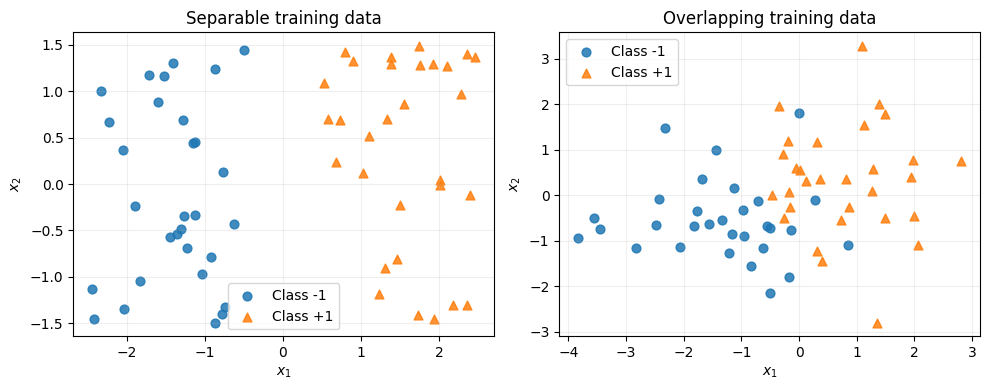

In [2]:
def scatter_data(ax, x, y):
    for label, color, marker in [(-1, "tab:blue", "o"), (1, "tab:orange", "^")]:
        ax.scatter(*x[y == label].T, c=color, marker=marker,
                   s=40, label=f"Class {label:+d}", alpha=0.85)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.grid(alpha=0.2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, x, y, title in zip(axes, [x_hard, x_soft], [y_hard, y_soft],
                         ["Separable training data", "Overlapping training data"]):
    scatter_data(ax, x, y)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

## 2. Model

Use the linear score and prediction:

$$
f(x)=w^\top x+b,\qquad
\hat y=\begin{cases}+1,&f(x)\geq0,\\-1,&f(x)<0.\end{cases}
$$

The decision boundary is $f(x)=0$; margin lines are $f(x)=\pm1$.
The distance from the boundary to either margin line is $1/\|w\|$.

In [3]:
def decision_function(x, w, b):
    return x @ w + b

def predict(x, w, b):
    return np.where(decision_function(x, w, b) >= 0, 1.0, -1.0)

def hinge_loss(y, scores):
    return np.maximum(0.0, 1.0 - y * scores)

### Shared evaluation and plotting functions

Run the following cell once. `evaluate` reports accuracy and optimization checks;
`plot_svm` shows margins and support vectors.
Each training section below defines its own fitting function.


In [4]:
def evaluate(model, x, y, x_test, y_test):
    w, b, C = model["w"], model["b"], model["C"]
    scores = decision_function(x, w, b)
    slack = hinge_loss(y, scores)
    primal = 0.5 * w @ w
    if C is not None:
        primal += C * slack.sum()
    print(f"Training accuracy: {100 * np.mean(predict(x, w, b) == y):.1f}%")
    print(f"Test accuracy:     {100 * np.mean(predict(x_test, w, b) == y_test):.1f}%")
    print(f"Margin (one side): {1 / np.linalg.norm(w):.4f}")
    print(f"Margin violations: {np.sum(slack > 1e-5)}/{len(y)}")
    print(f"Minimum y*f(x):    {np.min(y * scores):.6f}")
    print(f"Primal objective:  {primal:.6f}")
    print(f"Dual objective:    {model['dual']:.6f}")
    print(f"Primal-dual gap:   {primal - model['dual']:.2e}")
    print(f"Equality residual |sum(alpha*y)|: {abs(model['alpha'] @ y):.2e}")
    return slack



def plot_svm(ax, x, y, model, title):
    padding = 0.6
    xx, yy = np.meshgrid(
        np.linspace(x[:, 0].min() - padding, x[:, 0].max() + padding, 200),
        np.linspace(x[:, 1].min() - padding, x[:, 1].max() + padding, 200),
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = decision_function(grid, model["w"], model["b"]).reshape(xx.shape)
    ax.contourf(xx, yy, zz >= 0, levels=[-0.5, 0.5, 1.5],
                colors=["tab:blue", "tab:orange"], alpha=0.08)
    lines = ax.contour(xx, yy, zz, levels=[-1, 0, 1], colors="black",
                       linestyles=["--", "-", "--"], linewidths=[1, 1.5, 1])
    ax.clabel(lines, fmt={-1: "f=-1", 0: "f=0", 1: "f=1"}, fontsize=8)
    scatter_data(ax, x, y)
    sv = model["support"]
    ax.scatter(*x[sv].T, s=110, facecolors="none", edgecolors="black",
               linewidths=1, label="Support vector")
    wrong = predict(x, model["w"], model["b"]) != y
    if np.any(wrong):
        ax.scatter(*x[wrong].T, s=70, c="red", marker="x", label="Misclassified")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="best")

## 3. Hard-margin training

Use the **separable training data**. Every point must satisfy the margin constraint:

$$
\min_{w,b}\frac12\|w\|^2
\quad\text{subject to}\quad y_n(w^\top x_n+b)\geq1.
$$

Solve its dual QP:

$$
\max_{\alpha}\;D(\alpha)=\sum_n\alpha_n
-\frac12\sum_{n,m}\alpha_n\alpha_m y_n y_m x_n^\top x_m,
\qquad \alpha_n\geq0,\quad\sum_n\alpha_n y_n=0.
$$

SciPy minimizes $-D(\alpha)$. Recover $w=\sum_n\alpha_n y_n x_n$ and average
$b=y_s-w^\top x_s$ over support vectors with $\alpha_s>0$.

In [5]:
from scipy.optimize import minimize

def fit_svm_hard(x, y, print_every=1, verbose=True):
    N = len(y)
    Q = (y[:, None] * y[None, :]) * (x @ x.T)
    history = []

    def objective(alpha):
        return 0.5 * alpha @ Q @ alpha - alpha.sum()

    def gradient(alpha):
        return Q @ alpha - np.ones(N)

    def callback(alpha):
        value = -objective(alpha)
        history.append(value)
        if verbose and (len(history) == 1 or len(history) % print_every == 0):
            print(f"Iteration {len(history):3d}: dual objective = {value:.6f}")

    result = minimize(
        objective, np.zeros(N), jac=gradient, method="SLSQP",
        bounds=[(0.0, None)] * N,  # alpha_n >= 0
        constraints={"type": "eq", "fun": lambda a: y @ a,
                     "jac": lambda a: y},
        callback=callback,
        options={"maxiter": 1000, "ftol": 1e-10},
    )
    if not result.success:
        raise RuntimeError(f"SVM optimization failed: {result.message}")

    alpha = result.x
    support = alpha > 1e-6
    w = (alpha * y) @ x

    # Hard margin: every support vector satisfies y_n f(x_n) = 1.
    if not np.any(support):
        raise RuntimeError("No support vectors found; check the data and solver.")
    b = np.mean(y[support] - x[support] @ w)

    if verbose:
        print(f"Converged: dual objective = {-result.fun:.6f}; "
              f"support vectors = {support.sum()}/{N}")
    return dict(w=w, b=b, alpha=alpha, support=support, free=support.copy(),
                history=history, dual=-result.fun, C=None)

In [6]:
hard_model = fit_svm_hard(x_hard, y_hard)

Iteration   1: dual objective = -3977.792758
Iteration   2: dual objective = 1.199728
Iteration   3: dual objective = 1.490811
Iteration   4: dual objective = 1.646151
Iteration   5: dual objective = 1.698396
Iteration   6: dual objective = 1.720230
Iteration   7: dual objective = 1.788584
Iteration   8: dual objective = 1.790728
Iteration   9: dual objective = 1.792326
Iteration  10: dual objective = 1.792328
Iteration  11: dual objective = 1.792328
Iteration  12: dual objective = 1.792328
Converged: dual objective = 1.792328; support vectors = 3/60


## 4. Hard-margin results

Check training/test accuracy and $\min_n y_n f(x_n)\geq1$.
The feasible primal value $\frac12\|w\|^2$ should match the dual value up to numerical error.

In [7]:
hard_slack = evaluate(hard_model, x_hard, y_hard, x_hard_test, y_hard_test)

Training accuracy: 100.0%
Test accuracy:     100.0%
Margin (one side): 0.5282
Margin violations: 0/60
Minimum y*f(x):    1.000000
Primal objective:  1.792328
Dual objective:    1.792328
Primal-dual gap:   5.43e-08
Equality residual |sum(alpha*y)|: 3.66e-14


### Boundary and training trajectory

Solid: decision boundary. Dashed: margin lines. Black circles: support vectors.
Hard-margin support vectors lie on the margin. The dual objective is maximized.

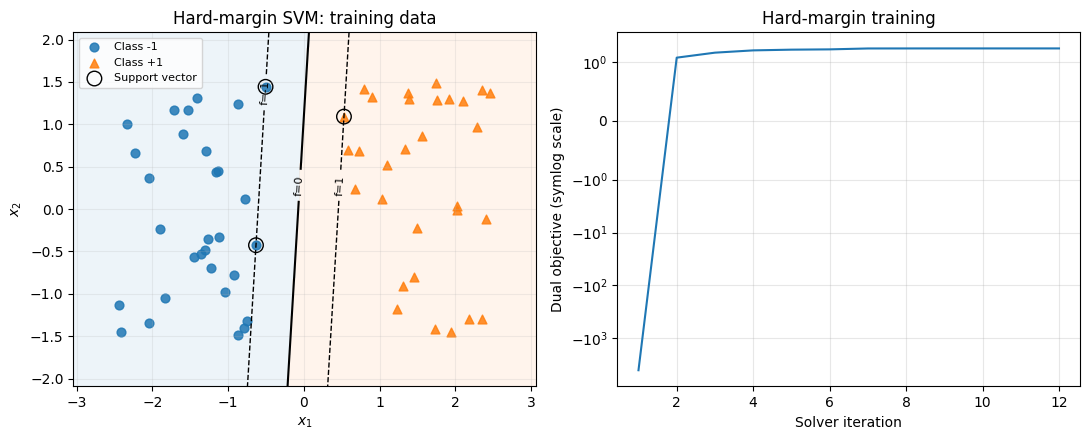

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_svm(axes[0], x_hard, y_hard, hard_model, "Hard-margin SVM: training data")
axes[1].plot(range(1, len(hard_model["history"]) + 1), hard_model["history"], color="tab:blue")
axes[1].set_yscale("symlog", linthresh=1)
axes[1].set(title="Hard-margin training", xlabel="Solver iteration",
            ylabel="Dual objective (symlog scale)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Soft-margin training

Use the **overlapping training data**. Allow margin violations with slack variables:

$$
\min_{w,b,\xi}\frac12\|w\|^2+C\sum_n\xi_n,
\qquad y_n f(x_n)\geq1-\xi_n,\quad\xi_n\geq0.
$$

Minimizing over $\xi_n$ gives $\xi_n=\max(0,1-y_n f(x_n))$, so equivalently:

$$
\min_{w,b}\frac12\|w\|^2+C\sum_n\max(0,1-y_n f(x_n)).
$$

The dual objective is unchanged, but its constraints become

$$
0\leq\alpha_n\leq C,\qquad\sum_n\alpha_n y_n=0.
$$

Recover $w$ as before. For $b$, use points with $0<\alpha_s<C$.
The helper uses KKT bounds if there are no such points.
$C>0$ controls the penalty for margin violations; the bias is not penalized.

In [9]:
def fit_svm_soft(x, y, C=1.0, print_every=1, verbose=True):
    if C <= 0:
        raise ValueError("C must be positive.")
    N = len(y)
    Q = (y[:, None] * y[None, :]) * (x @ x.T)
    history = []

    def objective(alpha):
        return 0.5 * alpha @ Q @ alpha - alpha.sum()

    def gradient(alpha):
        return Q @ alpha - np.ones(N)

    def callback(alpha):
        value = -objective(alpha)
        history.append(value)
        if verbose and (len(history) == 1 or len(history) % print_every == 0):
            print(f"Iteration {len(history):3d}: dual objective = {value:.6f}")

    result = minimize(
        objective, np.zeros(N), jac=gradient, method="SLSQP",
        bounds=[(0.0, C)] * N,  # 0 <= alpha_n <= C
        constraints={"type": "eq", "fun": lambda a: y @ a,
                     "jac": lambda a: y},
        callback=callback,
        options={"maxiter": 1000, "ftol": 1e-10},
    )
    if not result.success:
        raise RuntimeError(f"SVM optimization failed: {result.message}")

    alpha = result.x
    tol = min(1e-6, C * 1e-4)
    support = alpha > tol
    free = support & (alpha < C - tol)
    w = (alpha * y) @ x

    # Soft margin: use only support vectors with 0 < alpha_n < C.
    if np.any(free):
        b = np.mean(y[free] - x[free] @ w)
    else:
        # KKT gives an interval for b when every alpha is 0 or C.
        at_zero = alpha <= tol
        at_C = alpha >= C - tol
        candidate = y - x @ w
        lower = candidate[((y == 1) & at_zero) | ((y == -1) & at_C)]
        upper = candidate[((y == -1) & at_zero) | ((y == 1) & at_C)]
        b = 0.5 * (lower.max() + upper.min())

    if verbose:
        print(f"Converged: dual objective = {-result.fun:.6f}; "
              f"support vectors = {support.sum()}/{N}")
    return dict(w=w, b=b, alpha=alpha, support=support, free=free,
                history=history, dual=-result.fun, C=C)

In [10]:
C = 1.0
soft_model = fit_svm_soft(x_soft, y_soft, C=C)

Iteration   1: dual objective = -2329.018913
Iteration   2: dual objective = 14.717762
Iteration   3: dual objective = 14.372161
Iteration   4: dual objective = 15.861494
Iteration   5: dual objective = 15.934719
Iteration   6: dual objective = 15.953336
Iteration   7: dual objective = 15.968333
Iteration   8: dual objective = 15.976689
Iteration   9: dual objective = 15.977460
Iteration  10: dual objective = 15.980898
Iteration  11: dual objective = 15.982601
Iteration  12: dual objective = 15.982689
Iteration  13: dual objective = 15.982783
Iteration  14: dual objective = 15.982836
Iteration  15: dual objective = 15.982895
Iteration  16: dual objective = 15.982966
Iteration  17: dual objective = 15.983149
Iteration  18: dual objective = 15.983402
Iteration  19: dual objective = 15.983632
Iteration  20: dual objective = 15.983684
Iteration  21: dual objective = 15.983686
Iteration  22: dual objective = 15.983686
Iteration  23: dual objective = 15.983686
Iteration  24: dual objective =

## 6. Soft-margin results

Report accuracy, margin violations, and the primal-dual gap using
$P=\frac12\|w\|^2+C\sum_n\xi_n$.
SVM scores are **not probabilities**.

In [11]:
soft_slack = evaluate(soft_model, x_soft, y_soft, x_soft_test, y_soft_test)

Training accuracy: 91.7%
Test accuracy:     78.7%
Margin (one side): 0.5958
Margin violations: 16/60
Minimum y*f(x):    -1.746710
Primal objective:  15.983686
Dual objective:    15.983686
Primal-dual gap:   4.50e-08
Equality residual |sum(alpha*y)|: 2.20e-11


### Boundary and training trajectory

Soft-margin support vectors may lie on the margin, inside it, or on the wrong side of the boundary.
Red crosses mark misclassified training points.

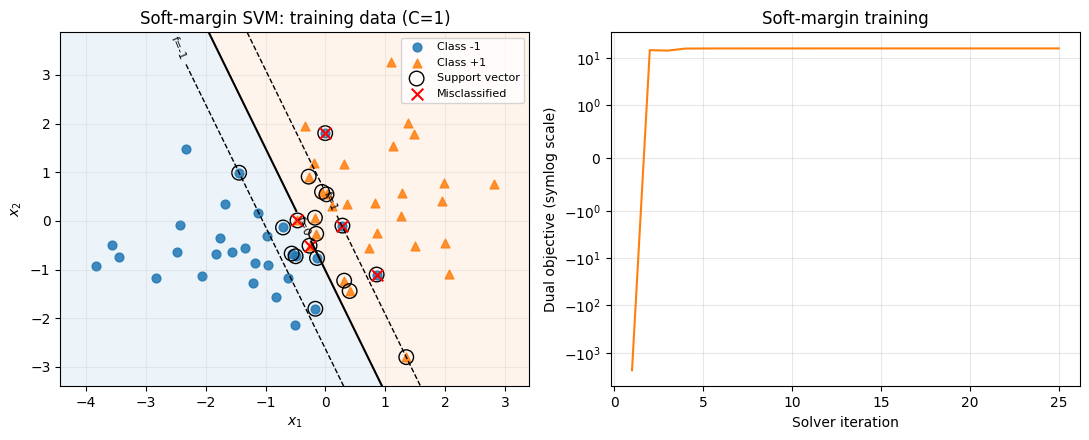

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_svm(axes[0], x_soft, y_soft, soft_model, f"Soft-margin SVM: training data (C={C:g})")
axes[1].plot(range(1, len(soft_model["history"]) + 1), soft_model["history"], color="tab:orange")
axes[1].set_yscale("symlog", linthresh=1)
axes[1].set(title="Soft-margin training", xlabel="Solver iteration",
            ylabel="Dual objective (symlog scale)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Inspect slack variables

| Minimum slack $\xi_n$ | Meaning |
|---|---|
| $0$ | On or outside the correct margin |
| $0<\xi_n<1$ | Inside the margin, correctly classified |
| $1$ | On the decision boundary |
| $>1$ | Misclassified |

Show the five largest training slacks. Slack measures a **functional margin violation**, not Euclidean distance.

In [13]:
scores = decision_function(x_soft, soft_model["w"], soft_model["b"])
indices = np.argsort(soft_slack)[-5:][::-1]
print(" index   true   predicted    y*f(x)     slack     alpha")
for i in indices:
    predicted = 1 if scores[i] >= 0 else -1
    print(f"{i:6d} {int(y_soft[i]):6d} {predicted:11d} "
          f"{y_soft[i] * scores[i]:9.3f} {soft_slack[i]:9.3f} "
          f"{soft_model['alpha'][i]:9.3f}")

 index   true   predicted    y*f(x)     slack     alpha
    31     -1           1    -1.747     2.747     1.000
    14     -1           1    -1.282     2.282     1.000
    49     -1           1    -1.015     2.015     1.000
    26      1          -1    -0.097     1.097     1.000
    41      1          -1    -0.088     1.088     1.000


### Hinge loss

A correctly classified point still receives positive loss when its margin score is below one.

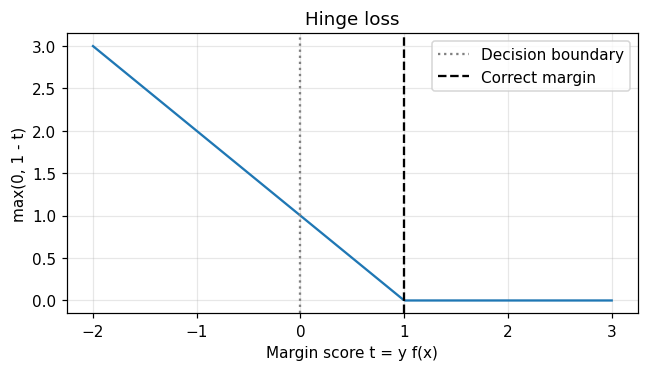

In [14]:
t = np.linspace(-2, 3, 300)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t, np.maximum(0, 1 - t), color="tab:blue")
ax.axvline(0, color="gray", linestyle=":", label="Decision boundary")
ax.axvline(1, color="black", linestyle="--", label="Correct margin")
ax.set(title="Hinge loss", xlabel="Margin score t = y f(x)", ylabel="max(0, 1 - t)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Both results comparison

Summarize the two demonstrations side by side.
**They use different datasets**, so their accuracy values do not rank the methods.

| | Hard margin | Soft margin |
|---|---|---|
| Training data | Separable | Overlapping |
| Margin violations | Not allowed | Penalized by $C$ |
| Dual bounds | $\alpha_n\geq0$ | $0\leq\alpha_n\leq C$ |
| Support vectors | On the margin | On/inside the margin, including errors |

Model / data               Train acc   Test acc    Margin  Violations   SVs
Hard / separable              100.0%     100.0%     0.528           0     3
Soft / overlapping             91.7%      78.7%     0.596          16    19


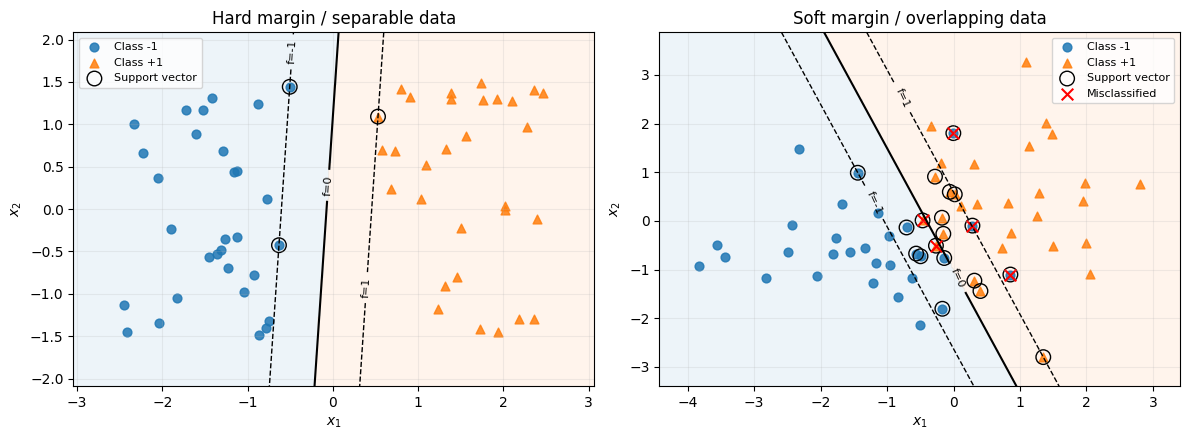

In [14]:
print(f"{'Model / data':<25} {'Train acc':>10} {'Test acc':>10} {'Margin':>9} {'Violations':>11} {'SVs':>5}")
for label, model, x, y, xt, yt in [
    ("Hard / separable", hard_model, x_hard, y_hard, x_hard_test, y_hard_test),
    ("Soft / overlapping", soft_model, x_soft, y_soft, x_soft_test, y_soft_test),
]:
    w, b = model["w"], model["b"]
    train_acc = np.mean(predict(x, w, b) == y)
    test_acc = np.mean(predict(xt, w, b) == yt)
    violations = np.sum(hinge_loss(y, decision_function(x, w, b)) > 1e-5)
    print(f"{label:<25} {train_acc:10.1%} {test_acc:10.1%} "
          f"{1 / np.linalg.norm(w):9.3f} {violations:11d} {model['support'].sum():5d}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_svm(axes[0], x_hard, y_hard, hard_model, "Hard margin / separable data")
plot_svm(axes[1], x_soft, y_soft, soft_model, "Soft margin / overlapping data")
plt.tight_layout()
plt.show()

### Compare soft-margin solutions

Use the **same training data** with three preset values of $C$.
A larger $C$ penalizes total slack more strongly; it need not improve classification accuracy.
Use validation data, not the test set, if choosing $C$ for a final model.

     C    margin   total slack   support vectors
  0.01     2.267        31.728                52
  0.10     0.945        18.244                30
 10.00     0.489        14.283                16


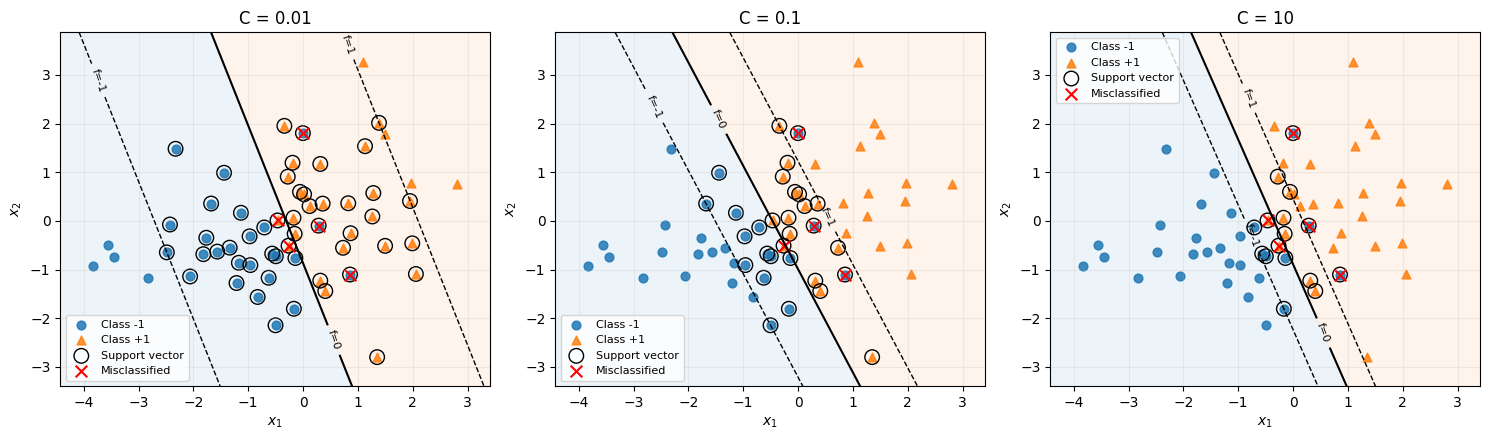

In [15]:
C_values = [0.01, 0.1, 10.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
print("     C    margin   total slack   support vectors")
for ax, c in zip(axes, C_values):
    model = fit_svm_soft(x_soft, y_soft, C=c, verbose=False)
    slack = hinge_loss(y_soft, decision_function(x_soft, model["w"], model["b"]))
    margin = 1 / np.linalg.norm(model["w"])
    print(f"{c:6.2f} {margin:9.3f} {slack.sum():13.3f} {model['support'].sum():17d}")
    plot_svm(ax, x_soft, y_soft, model, f"C = {c:g}")
plt.tight_layout()
plt.show()